In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

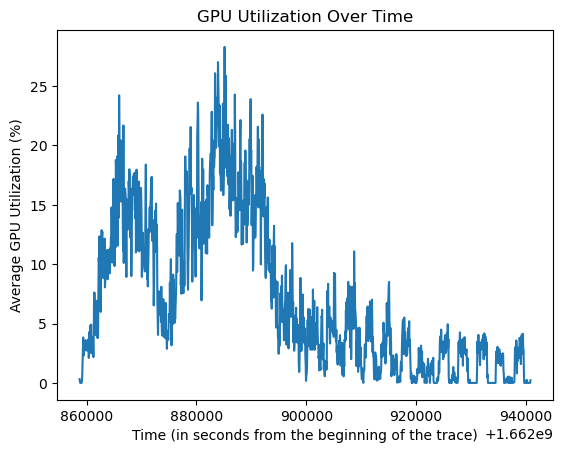

In [ ]:
df = pd.read_csv("pod_gpu_duty_cycle_anon.csv")

df["timestamp_anon"] = pd.to_numeric(df["timestamp_anon"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")

#remove rows where timestamp is missing or "value" is missing"
df = df.dropna(subset=["timestamp_anon", "value"])

# sort table by time
df = df.sort_values("timestamp_anon")

BIN_SIZE = 60

df["time_bin"] = (df["timestamp_anon"] // BIN_SIZE) * BIN_SIZE

#group data by each time_bin
util_ts = df.groupby("time_bin")["value"].mean().reset_index()

plt.figure()
plt.plot(util_ts["time_bin"], util_ts["value"])
plt.xlabel("Time (in seconds from the beginning of the trace)")
plt.ylabel("Average GPU Utilization (%)")
plt.title("GPU Utilization Over Time")
plt.show()